In [1]:
# curl "https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent" \
#   -H 'Content-Type: application/json' \
#   -H 'X-goog-api-key: GEMINI_API_KEY' \
#   -X POST \
#   -d '{
#     "contents": [
#       {
#         "parts": [
#           {
#             "text": "Explain how AI works in a few words"
#           }
#         ]
#       }
#     ]
#   }'

API KEY 테스트

In [11]:
import requests
from dotenv import load_dotenv
import os

load_dotenv()

client = os.getenv("GOOGLE_AI_API_KEY")
request_url = "https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent"
headers = {
    'Content-Type': 'application/json',
    'X-goog-api-key': client
}
data = {
    "contents": [
        {
            "parts": [
                {
                    "text": "Explain how AI works in a few words"
                }
            ]
        }
    ]
}

In [3]:
response = requests.post(request_url, headers=headers, json=data)
print(response.json())

{'candidates': [{'content': {'parts': [{'text': 'AI learns from data to make predictions or decisions.\n'}], 'role': 'model'}, 'finishReason': 'STOP', 'avgLogprobs': -0.09420799125324596}], 'usageMetadata': {'promptTokenCount': 8, 'candidatesTokenCount': 11, 'totalTokenCount': 19, 'promptTokensDetails': [{'modality': 'TEXT', 'tokenCount': 8}], 'candidatesTokensDetails': [{'modality': 'TEXT', 'tokenCount': 11}]}, 'modelVersion': 'gemini-2.0-flash', 'responseId': 'nk3JaJu7O7qmqtsPlYHO0A8'}


NANO BANANA 로 광고 이미지 생성 테스트

In [ ]:
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO

keyword = "handcream"
client = genai.Client(api_key=os.getenv("GOOGLE_AI_API_KEY"))
prompt = (
    f"After picking this {keyword} object, "
    "make it a good commercial image",
)

image = Image.open("../../data/ad_images/handcream.png")
try:
    response = client.models.generate_content(
        model="gemini-2.5-flash-image-preview",
        contents=[prompt, image],
    )
except Exception as e:
    print(e)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save("generated_image.png")

In [9]:
from google import genai
from google.genai import types
from PIL import Image
from io import BytesIO
import uuid
import os

keyword = "sandwich"
client = genai.Client(api_key=os.getenv("GOOGLE_AI_API_KEY"))
prompt = (
    f"After picking this {keyword} object, "
    "make it a good commercial image.",
)

image = Image.open("C:/Users/user/Downloads/tousresjoures_sandwich.jpg")
try:
    response = client.models.generate_content(
        model="gemini-2.5-flash-image-preview",
        contents=[prompt, image],
    )
except Exception as e:
    print(e)

In [10]:
import json

save_image_path = f"../../data/ad_images/{keyword}_{str(uuid.uuid4())}.png"

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    elif part.inline_data is not None:
        image = Image.open(BytesIO(part.inline_data.data))
        image.save(save_image_path)

        ### 이미지와 광고 데이터를 json에 저장
        # 1. 파일 경로 설정
        json_file_path = "../../data/json/ad_data.json"

        # 2. 기존 json 데이터 읽기(파일이 없으면 빈 리스트로 초기화)
        try:
            with open(json_file_path, 'r', encoding="utf-8") as f:
                data = json.load(f)
        except (FileNotFoundError, json.JSONDecodeError):
            data = []
        
        # 3. 새로운 데이터 객체 생성
        new_entity = {
            "id": len(data) + 1,
            "company": "뚜레쥬르",
            "product": "크랜베리치킨 샌드위치",
            "category": "sandwich",
            "image_path": save_image_path
        }

        data.append(new_entity)

        # 5. 변경된 데이터를 json 파일에 쓰기
        with open(json_file_path, "w", encoding="utf-8") as f:
            json.dump(data, f, indent=4, ensure_ascii=False)
        
        print(f"새로운 데이터가 '{json_file_path}' 파일에 추가되었습니다.")

Here's a commercial image of the sandwich, ready for advertising! 
새로운 데이터가 '../../data/json/ad_data.json' 파일에 추가되었습니다.


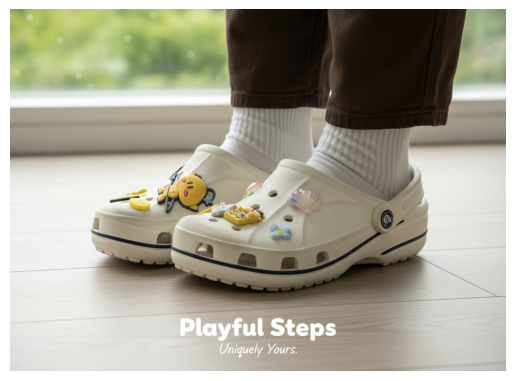

In [12]:
import cv2
import matplotlib.pyplot as plt
image_path = "C:/Users/user/potenup/sep_project/Potenup_CV_LLM_Project/data/ad_images/75c6b440-2510-4946-aa65-11bfd56a2ade_shoes.png"
generated_ad_image = cv2.imread(image_path)
generated_ad_image = cv2.cvtColor(generated_ad_image, cv2.COLOR_BGR2RGB)

plt.imshow(generated_ad_image)
plt.axis("off")
plt.show()

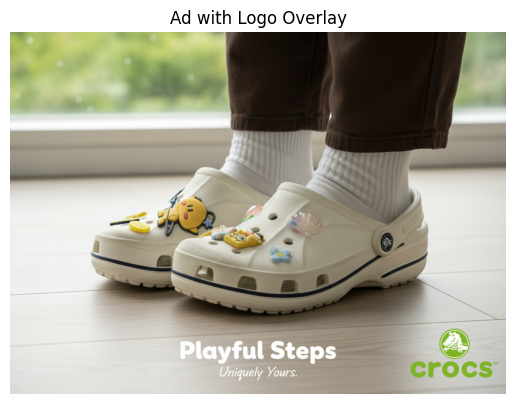

In [30]:
import numpy as np

image_path = "C:/Users/user/potenup/sep_project/Potenup_CV_LLM_Project/data/ad_images/75c6b440-2510-4946-aa65-11bfd56a2ade_shoes.png"
logo_path = "C:/Users/user/potenup/sep_project/Potenup_CV_LLM_Project/data/logos/crocs_logo.png"

# --------- 광고이미지와 로고이미지 가져오기 --------------#
generated_ad_image = cv2.imread(image_path)
if generated_ad_image is None:
    raise FileNotFoundError(f"Failed to open image file: {image_path}")
generated_ad_image = cv2.cvtColor(generated_ad_image, cv2.COLOR_BGR2RGB)

logo_image = cv2.imread(logo_path, cv2.IMREAD_UNCHANGED)
if logo_image is None:
    raise FileNotFoundError(f"Failed to open logo image file: {logo_path}")

#------ 로고 크기 및 위치 설정 ------#
logo_width = 230
aspect_ratio = logo_image.shape[1] / logo_image.shape[0] # 가로/세로 비율
logo_height = int(logo_width / aspect_ratio)

# 로고 리사이즈
resized_logo = cv2.resize(logo_image, (logo_width, logo_height), interpolation=cv2.INTER_AREA)

# 로고를 삽입할 광고 이미지의 오른쪽 하단 위치 설정
y_offset, x_offset = 10, 10 # 하단 오른쪽 마진

# 광고 이미지와 로고 이미지의 크기 가져오기
ad_height, ad_width, _ = generated_ad_image.shape
logo_height, logo_width = resized_logo.shape[0], resized_logo.shape[1]

# ------ 로고 삽입 좌표 계산 (오른쪽 하단 기준) ------ #
y1 = ad_height - logo_height - y_offset
x1 = ad_width - logo_width - x_offset
y2 = ad_height - y_offset
x2 = ad_width - x_offset

# 영역이 광고 이미지 범위를 벗어나지 않도록 조종
if y2 > ad_height : y2 = ad_height
if x2 > ad_width : x2 = ad_width

#-------------- 알파블랜딩 수행 ---------------#
# 로고의 BGR과 알파 채널을 분리
if resized_logo.shape[2] == 4:
    b, g, r, alpha = cv2.split(resized_logo)
    # 알파채널을 0.0 ~ 1.0 범위로 정규화
    overlay_rgb = cv2.merge((r, g, b)) # 로고의 채널 순서를 RGB로 변경
    alpha_normalized = alpha / 255.0

else:
    # 알파 채널이 없는 경우 (투명도가 없는 경우)
    overlay_rgb = resized_logo
    alpha_normalized = np.ones(overlay_rgb.shape[:2], dtype=overlay_rgb.dtype)

# 광고 이미지에서 로고를 덮어쓸 영역 (ROI)
roi = generated_ad_image[y1:y2, x1:x2]

# roi와 overlay_rgb의 크기를 맞춰줌 (만약 경계조정으로 크기가 달라졌다면)
overlay_rgb_cropped = overlay_rgb[:roi.shape[0], :roi.shape[1]]
alpha_normalized_cropped = alpha_normalized[:roi.shape[0], :roi.shape[1]]

# 알파 블렌딩 수식을 적용: 새로운 픽셀 = (원래 픽셀 * (1 - 알파)) + (오버레이 픽셀 * 알파) 
for c in range(0, 3):
    roi[:, :, c] = (roi[:, :, c] * (1 - alpha_normalized_cropped) + overlay_rgb_cropped[:, :, c] * alpha_normalized_cropped)

# --------- 결과 이미지 표시 ---------- #
plt.imshow(generated_ad_image)
plt.axis("off")
plt.title("Ad with Logo Overlay")
plt.show()
